# Customer Segmentation & Marketing Campaign Analytics
## Phase 4 — Segment x Campaign Performance

**Goal of this notebook.** Phase 3 grouped customers by engagement history. This notebook asks the
business question directly: **for each segment, how much calling effort did it receive this
campaign, and how much did that effort actually deliver?** Size and response rate alone don't say
whether a segment's results were reasonable for what was spent contacting it — a large segment
with a below-average response rate could still be "worth it" if it barely got called, or a wasted
effort if it absorbed most of the campaign's calls. This notebook puts effort and results side by
side to say which.

**Input.** `bank_clean` joined to `customer_segments` (both built by earlier notebooks).

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.db import connect, run_sql_file

pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
con = connect()

## 1. Effort and results, side by side

`sql/14_segment_response_and_effort.sql` computes, per segment: how many customers, how many total
contacts this campaign, how many subscribed, and two numbers that combine the two sides —
**contacts per subscriber** (how many calls it took to land one) and an **efficiency index**
(the segment's share of all subscribers gained, divided by its share of all contacts made; above
1 means the segment delivered more results than its share of effort, below 1 means less).

In [2]:
perf = run_sql_file(con, "14_segment_response_and_effort.sql")
perf

,segment_name,n_customers,pct_of_customers,total_contacts,pct_of_all_contacts,n_subscribers,pct_of_all_subscribers,subscribe_rate_pct,contacts_per_subscriber,efficiency_index
0,Warm: Past Success,1511,3.3,2729.0,2.2,978.0,18.5,64.73,2.8,8.47
1,Warm: Past Mixed Outcome,1840,4.1,4529.0,3.6,307.0,5.8,16.68,14.8,1.60
2,Warm: Past No,4903,10.8,9712.0,7.8,618.0,11.7,12.60,15.7,1.50
3,Cold: Never Contacted,36957,81.7,107986.0,86.4,3386.0,64.0,9.16,31.9,0.74


**What this shows, segment by segment:**

- **Warm: Past Success** converts at **64.7%**, needs only **2.8 contacts per subscriber**, and
  has an efficiency index of **8.47** — it delivered 18.5% of all subscribers gained from just
  2.2% of all contacts made.
- **Warm: Past Mixed Outcome** and **Warm: Past No** sit in between: above-average response
  (16.7% and 12.6%, both over the 11.7% overall average) and efficiency indexes above 1 (1.60 and
  1.50) — genuinely useful segments to call, just not spectacular ones.
- **Cold: Never Contacted** converts at **9.2%**, below the overall average, needs **31.9 contacts
  per subscriber** — over 11 times as many as "Past Success" — and has an efficiency index of
  **0.74**: it absorbed 86.4% of all campaign calling effort while returning only 64.0% of all
  subscribers.

## 2. The headline contrast

This is the plain-English version of the table above, and the contrast this phase set out to
surface: **a segment that is small but highly responsive, next to one that is large but low-yield.**

In [3]:
top = perf.iloc[0]     # Warm: Past Success
bottom = perf[perf.segment_name == "Cold: Never Contacted"].iloc[0]

lift_vs_cold = top.subscribe_rate_pct / bottom.subscribe_rate_pct
print(f"'{top.segment_name}' customers were {lift_vs_cold:.1f}x more likely to subscribe than")
print(f"'{bottom.segment_name}' customers ({top.subscribe_rate_pct:.1f}% vs. {bottom.subscribe_rate_pct:.1f}%),")
print(f"yet they received only {top.pct_of_all_contacts:.1f}% of all contacts made this campaign,")
print(f"while '{bottom.segment_name}' — {bottom.pct_of_customers:.0f}% of all customers — absorbed {bottom.pct_of_all_contacts:.1f}% of the calling effort")
print(f"for a below-average {bottom.subscribe_rate_pct:.1f}% return.")

'Warm: Past Success' customers were 7.1x more likely to subscribe than
'Cold: Never Contacted' customers (64.7% vs. 9.2%),
yet they received only 2.2% of all contacts made this campaign,
while 'Cold: Never Contacted' — 82% of all customers — absorbed 86.4% of the calling effort
for a below-average 9.2% return.


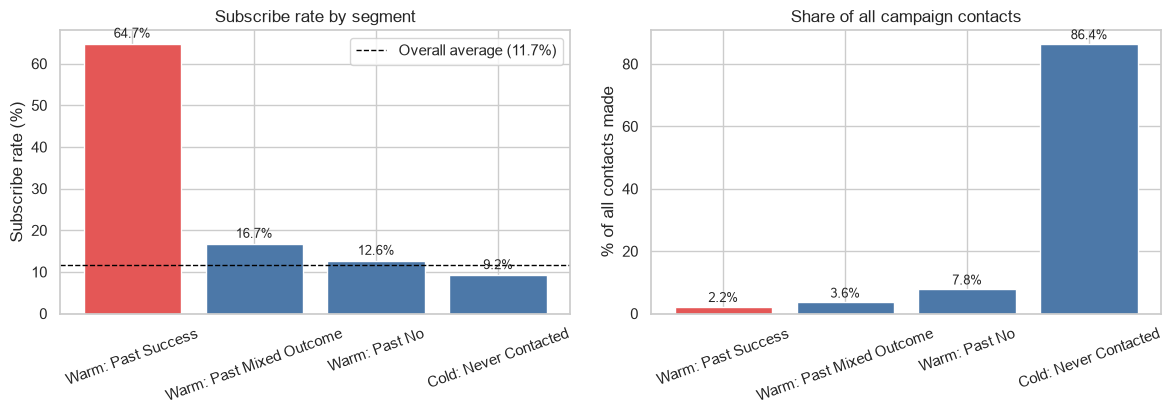

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
order = perf.sort_values("subscribe_rate_pct", ascending=False).segment_name
colors = ["#E45756" if s == "Warm: Past Success" else "#4C78A8" for s in order]

p = perf.set_index("segment_name").loc[order]
axes[0].bar(order, p.subscribe_rate_pct, color=colors)
axes[0].axhline(11.7, color="black", ls="--", lw=1, label="Overall average (11.7%)")
for i, v in enumerate(p.subscribe_rate_pct):
    axes[0].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)
axes[0].set_title("Subscribe rate by segment"); axes[0].set_ylabel("Subscribe rate (%)")
axes[0].tick_params(axis="x", rotation=20); axes[0].legend()

axes[1].bar(order, p.pct_of_all_contacts, color=colors)
for i, v in enumerate(p.pct_of_all_contacts):
    axes[1].text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)
axes[1].set_title("Share of all campaign contacts"); axes[1].set_ylabel("% of all contacts made")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../reports/04_response_vs_effort.png", dpi=150)
plt.show()

## 3. Sanity check: is this just the same finding as `poutcome`, restated?

Segments were built from `poutcome` (among other things), so it's fair to ask whether this phase
has added anything beyond Phase 2's finding that `poutcome = success` converts at 64.7%. Two things
here go beyond that:

1. **The effort side.** Phase 2 never looked at how much calling effort each `poutcome` group
   absorbed — that required joining response *rate* to campaign *volume*, which is what
   `contacts_per_subscriber` and `efficiency_index` add.
2. **Segments blend recency and frequency with prior outcome, not just prior outcome alone.**
   Two customers with the same `poutcome` can land in different segments if their recency or
   contact frequency differs enough — the segment boundaries in Phase 3 (Section 5) show this:
   `poutcome_success` averages 1.0 within "Warm: Past Success" but the segment's `recency_days`
   and `campaign_capped` values are its own, not shared with the raw `poutcome` category.

In [5]:
con.execute("SELECT COUNT(*) FROM customer_segments s JOIN bank_clean c USING (customer_id) WHERE s.segment_name = 'Warm: Past Success' AND c.poutcome != 'success'").fetchone()

(0,)

In this dataset, that count is 0 — every "Warm: Past Success" customer does have `poutcome =
success`, because prior outcome so strongly dominates the clustering (Phase 3, Section 3) that the
segment boundary and the `poutcome` category end up identical here. The added value in this phase
is genuinely the **effort side of the analysis** (contacts per subscriber, efficiency index), not a
different customer grouping — worth stating plainly rather than overselling the segmentation.

## Phase 4 summary

**The headline number:** customers who said yes to a previous campaign were **7.1x more likely**
to subscribe than customers never contacted before (64.7% vs. 9.2%) — yet they received only
**2.2%** of all campaign contacts. Meanwhile "Cold: Never Contacted" customers, **82% of the
customer base**, absorbed **86% of all calling effort** for a below-average 9.2% return.

- **Small but highly responsive:** "Warm: Past Success" — 3.3% of customers, 64.7% response,
  efficiency index 8.47 (it delivered far more subscribers than its share of calling effort).
- **Large but low-yield:** "Cold: Never Contacted" — 81.7% of customers, 9.2% response (below the
  11.7% average), efficiency index 0.74.
- **Two middling-but-genuinely-useful segments:** "Warm: Past No" and "Warm: Past Mixed Outcome"
  both convert above the overall average and have an efficiency index above 1 — not spectacular,
  but a better use of a call than an average cold contact.
- This phase's real addition is the **effort side**: joining response rate to how many calls a
  segment actually cost, which Phase 2's category-by-category rates never did. The customer
  grouping itself, checked directly, turns out to line up exactly with `poutcome` for the "Past
  Success" segment in this dataset — the effort analysis, not a different grouping, is what's new
  here.